In [38]:
import geopandas as gpd
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append('../src')
import importlib
import ntl_functions

importlib.reload(ntl_functions)
from ntl_functions import plot_NASA_NTL, filter_dataset_by_bounding_box, mask_dataset_by_geometry, yearly_radiance, yearly_nonzero_pixels


In [39]:
somaliland_shp_berbera = gpd.read_file(
    "../data/Combined_Datasets/Somaliland_with_berbera/somaliland_with_berbera.shp"
)

SL_berbera = xr.open_dataset("../data/NTL_Data/141225_SL_Berbera_VNP46A4_EY_2012_24.nc")

logged_NTL = xr.where(
    SL_berbera.isnull(), 
    np.nan,
    xr.where(
        SL_berbera > 0,
        np.log(SL_berbera),
        0
    )
)


region_geoms = {
    region: somaliland_shp_berbera.loc[
        somaliland_shp_berbera["admin1Name"] == region
    ]
    for region in somaliland_shp_berbera["admin1Name"].unique()
}
regions = {}
regions_logged = {}

for region, geom in region_geoms.items():
    masked_ntl = mask_dataset_by_geometry(SL_berbera, geom)
    masked_ntl_logged = mask_dataset_by_geometry(logged_NTL, geom)

    regions[region] = filter_dataset_by_bounding_box(masked_ntl, geom)
    regions_logged[region] = filter_dataset_by_bounding_box(masked_ntl_logged, geom)



#Cities
city_shapefiles = {
    "Hargeisa": "../data/Combined_Datasets/Hargeisa_shp/HGA.shp",
    "Berbera": "../data/Combined_Datasets/Berbera_shp/Berbera.shp",
    "Burao": "../data/Combined_Datasets/Burao_shp/Burao.shp",
    "Boroma": "../data/Combined_Datasets/Boroma_shp/Boroma.shp",
    "Erigavo": "../data/Combined_Datasets/Erigavo_shp/Erigavo.shp",
    "Las_Anod": "../data/Combined_Datasets/Las_Anod_shp/Las_Anod.shp",
}

cities = {
    city: gpd.read_file(path)
    for city, path in city_shapefiles.items()
}


cities_ntl = {}
cities_ntl_logged = {}

for city, geom in cities.items():
    cities_ntl[city] = filter_dataset_by_bounding_box(SL_berbera, geom)
    cities_ntl_logged[city] = filter_dataset_by_bounding_box(logged_NTL, geom)


c:\Users\samsa\Documents\NTL_Somaliland\venv\Lib\site-packages\xarray\computation\apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


## Somaliland

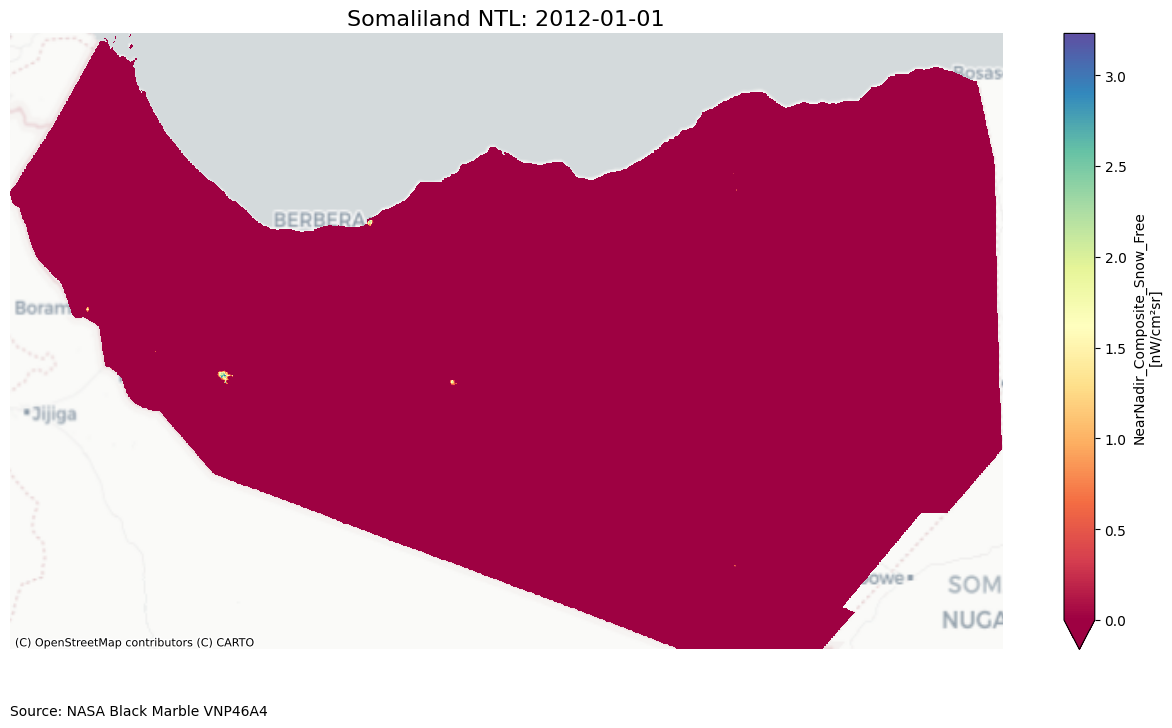

In [31]:
plot_NASA_NTL(logged_NTL, somaliland_shp_berbera, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0)
plt.savefig(f'../output/Graphics/SL_2012_logged.png', dpi=300, bbox_inches='tight')  

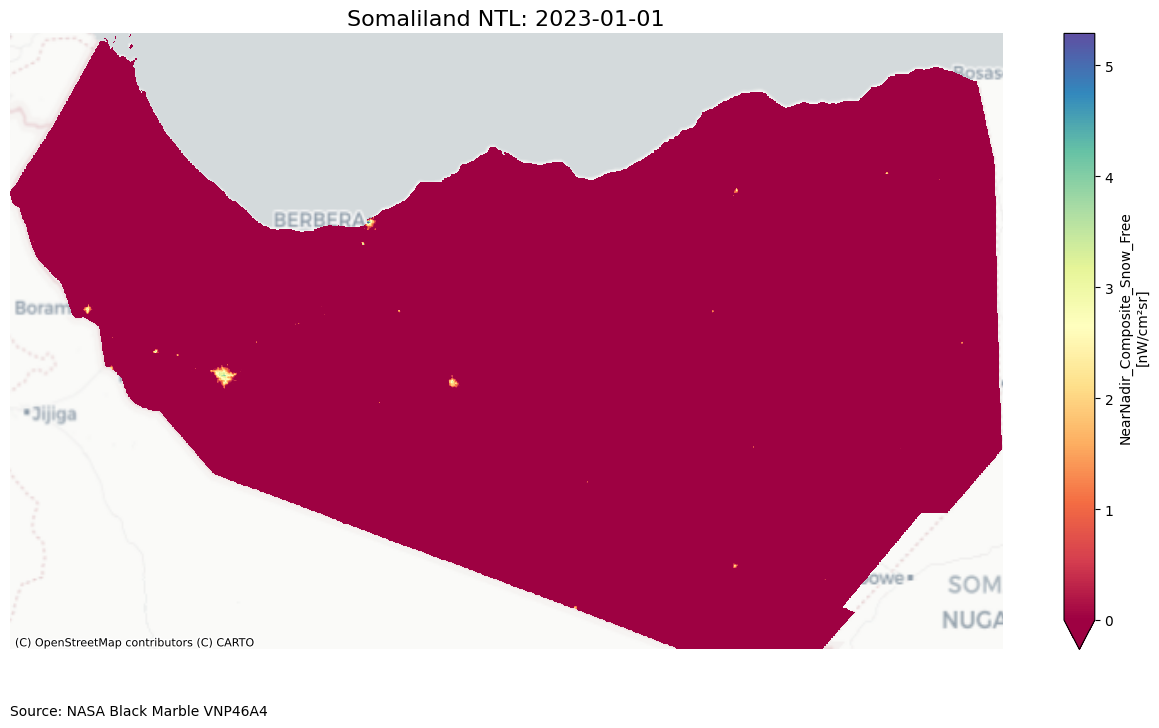

In [32]:
plot_NASA_NTL(logged_NTL, somaliland_shp_berbera, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0)
plt.savefig(f'../output/Graphics/SL_2023_logged.png', dpi=300, bbox_inches='tight')  

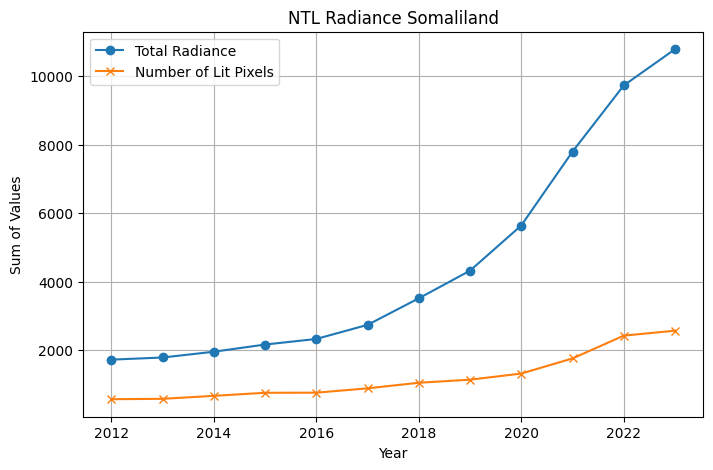

<Figure size 640x480 with 0 Axes>

In [33]:
plt.figure(figsize=(8,5))
plt.plot(SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).time.to_index(), SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).values, marker="o")
plt.plot(SL_berbera["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).time.to_index(), (SL_berbera["NearNadir_Composite_Snow_Free"] > 0).sum(dim=["x", "y"]).values, marker="x")
plt.title("NTL Radiance Somaliland")
plt.xlabel("Year")
plt.ylabel("Sum of Values")
plt.legend(["Total Radiance", "Number of Lit Pixels"])
plt.grid(True)
plt.show()
plt.savefig(f'../output/Graphics/SL_Total_Pixels_Rad.png', dpi=300, bbox_inches='tight')  

## Regional

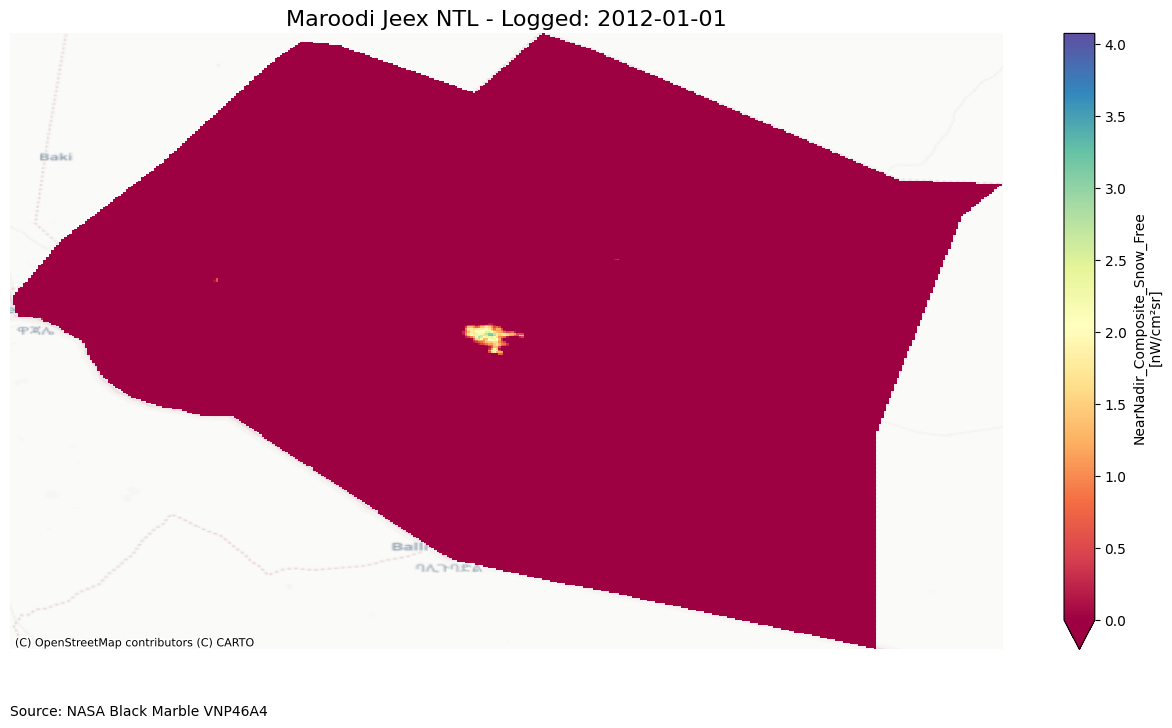

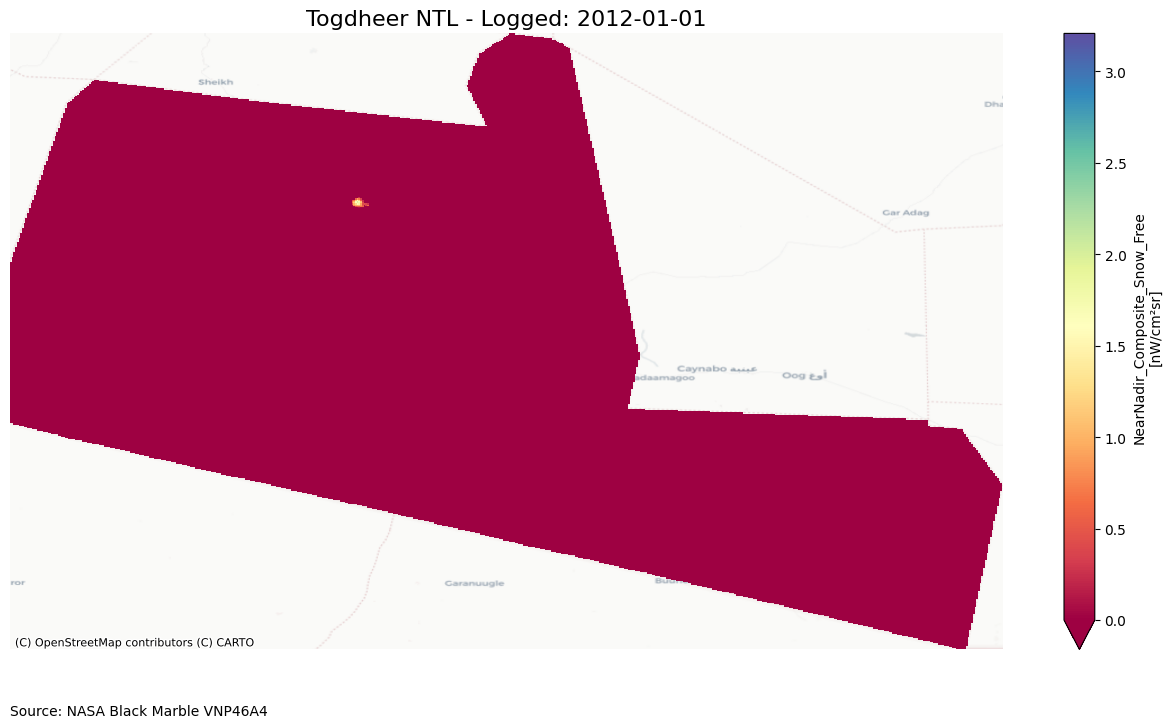

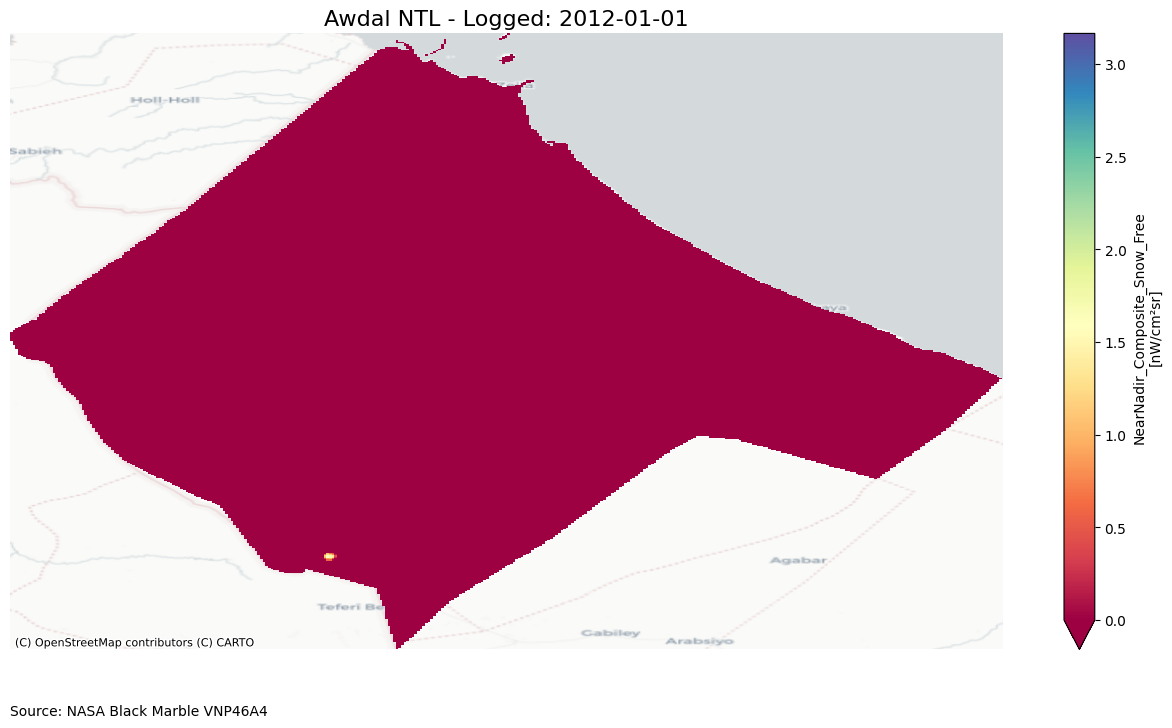

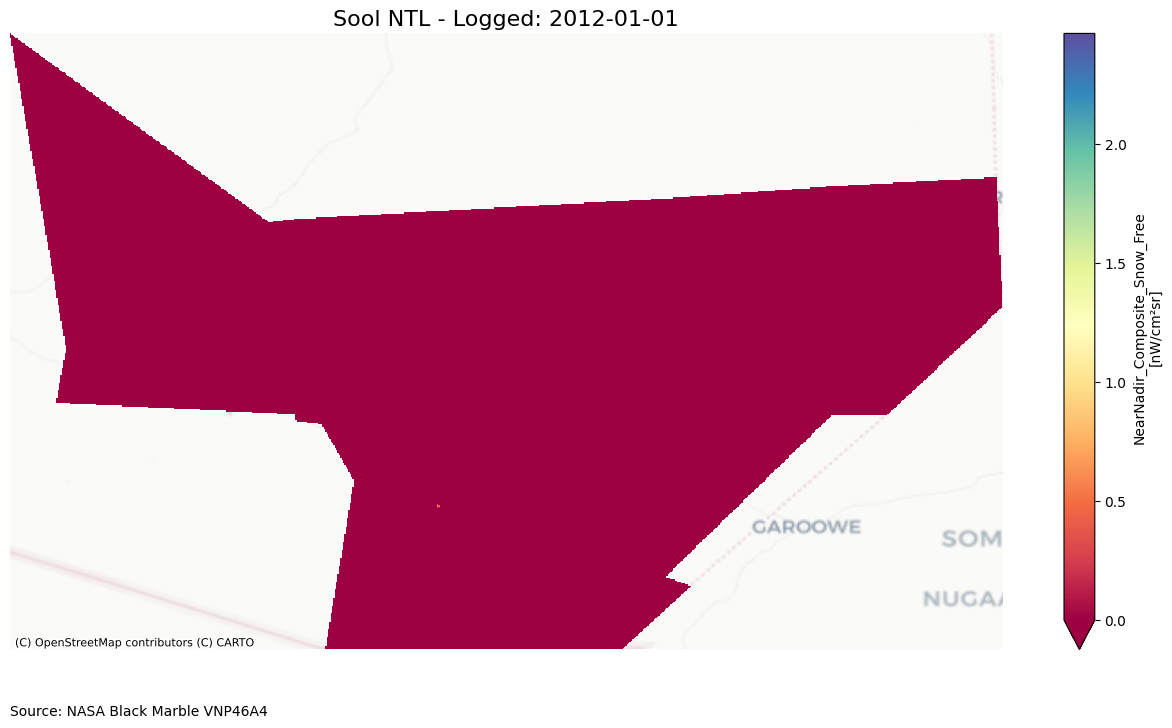

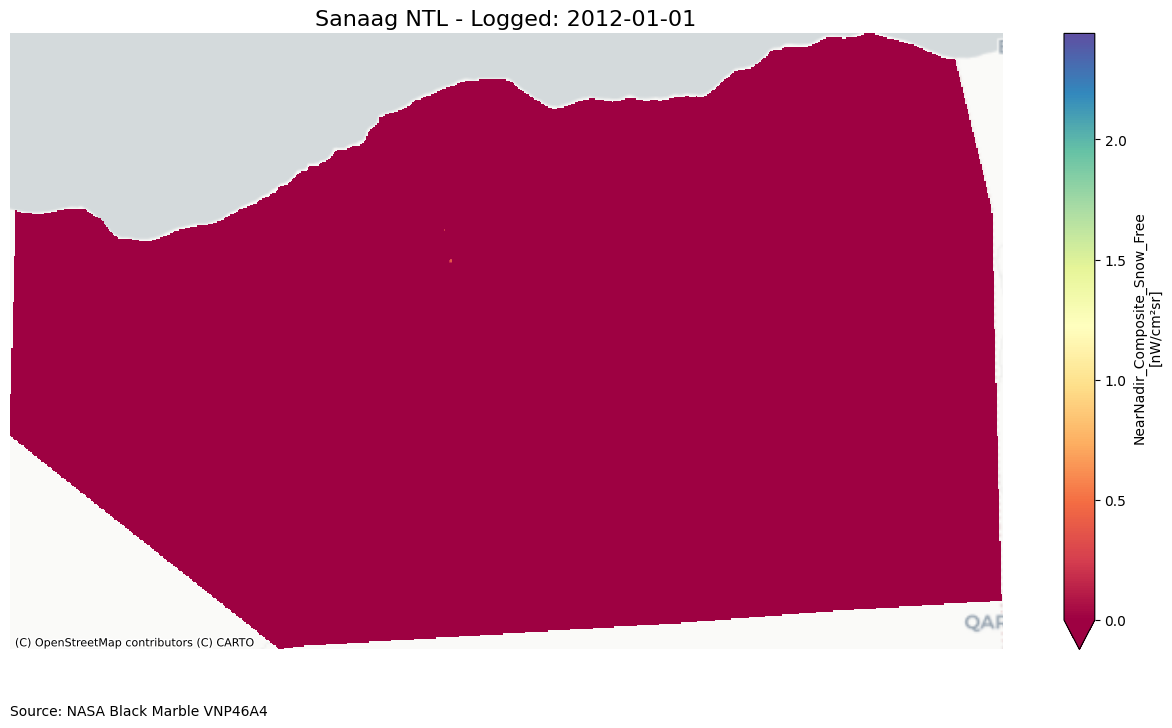

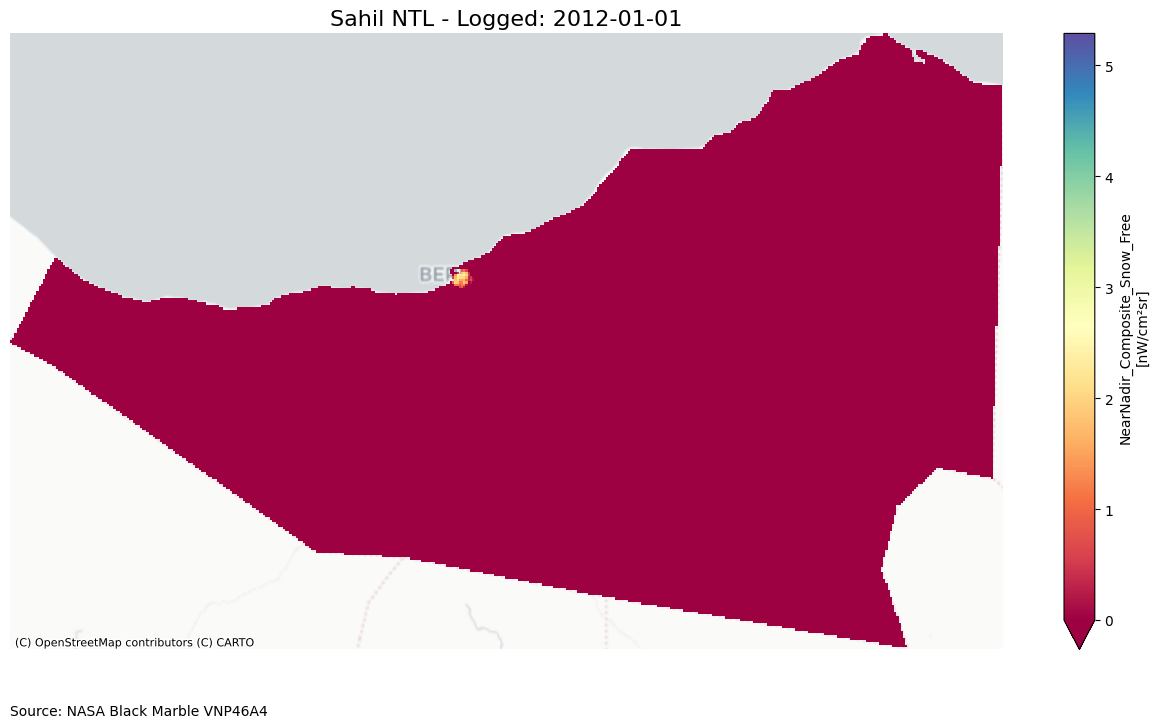

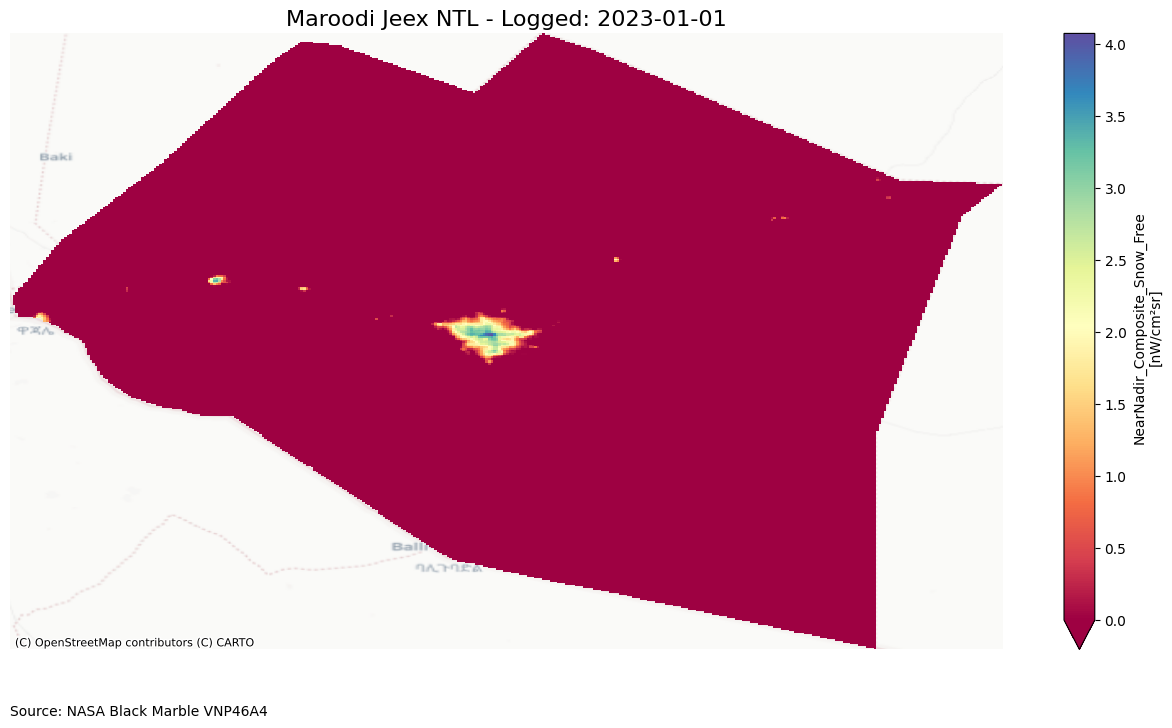

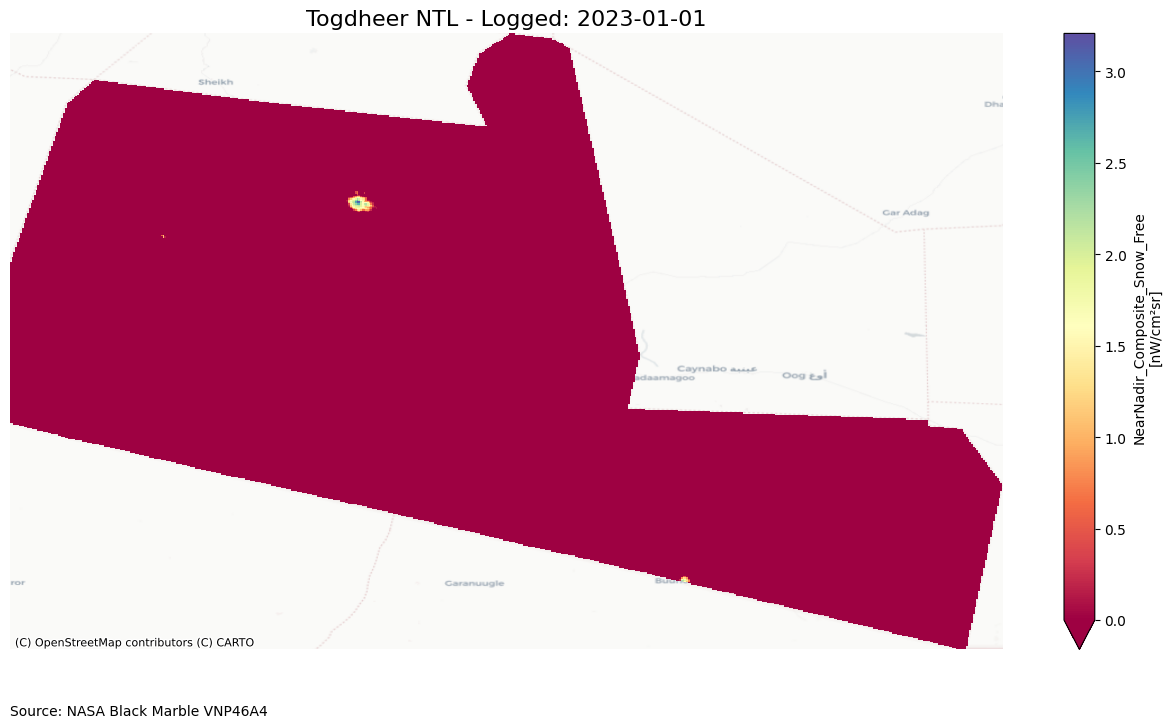

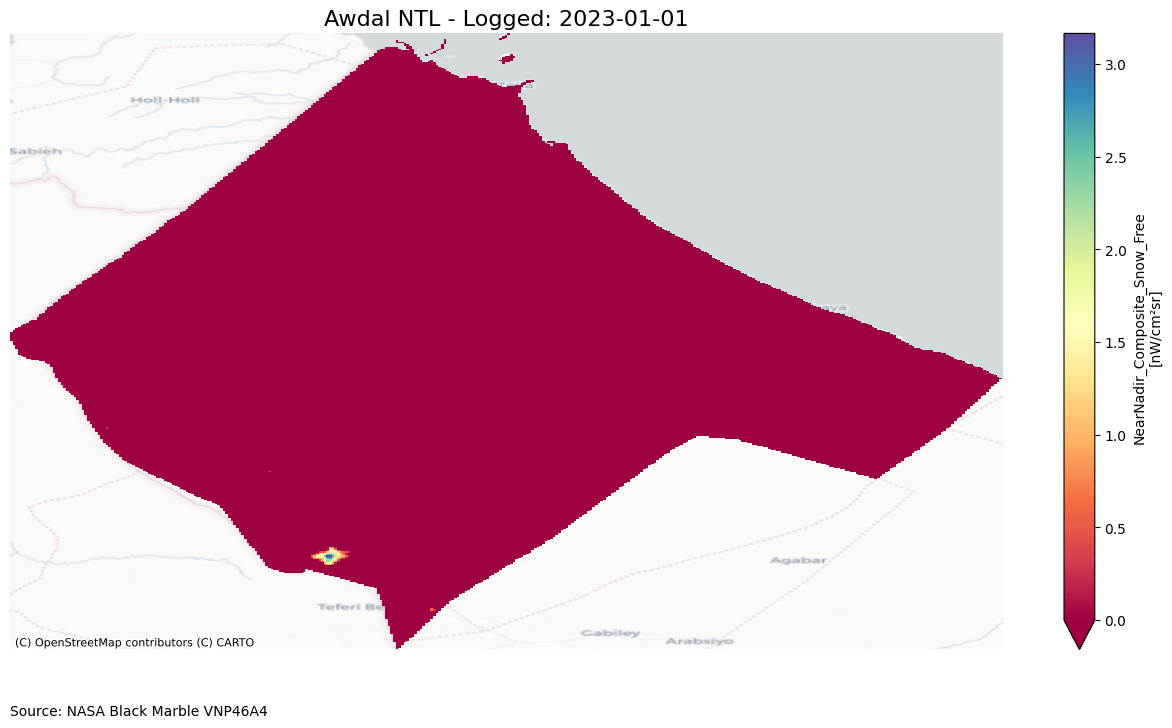

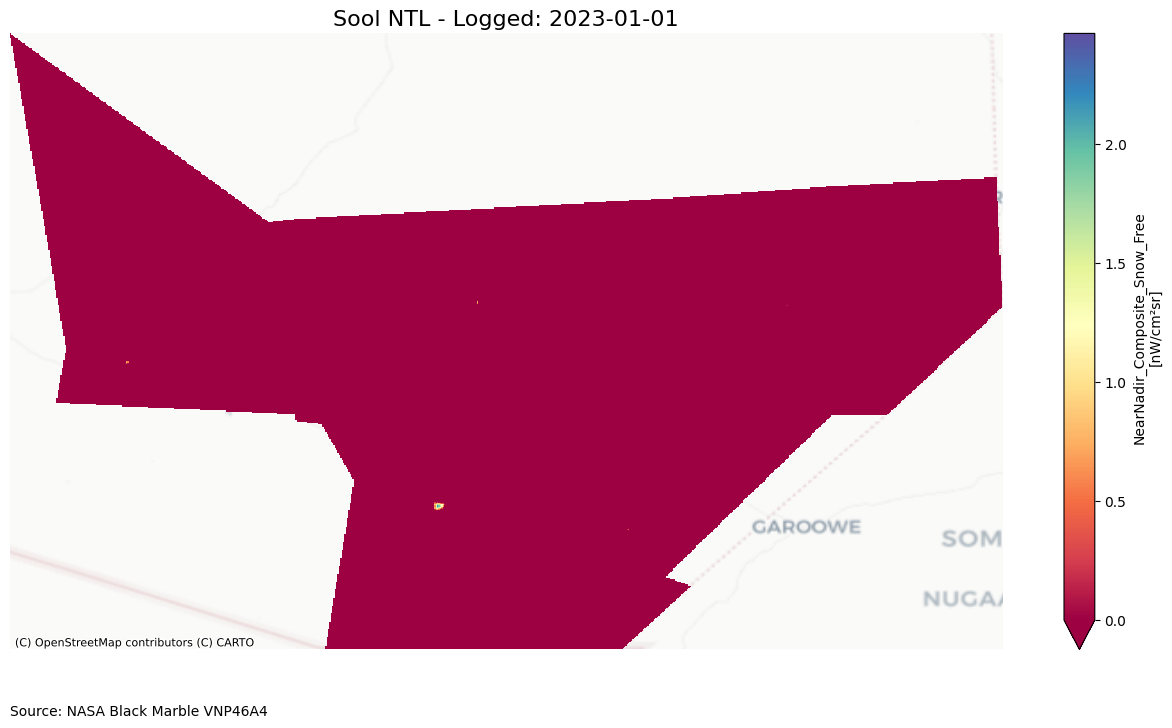

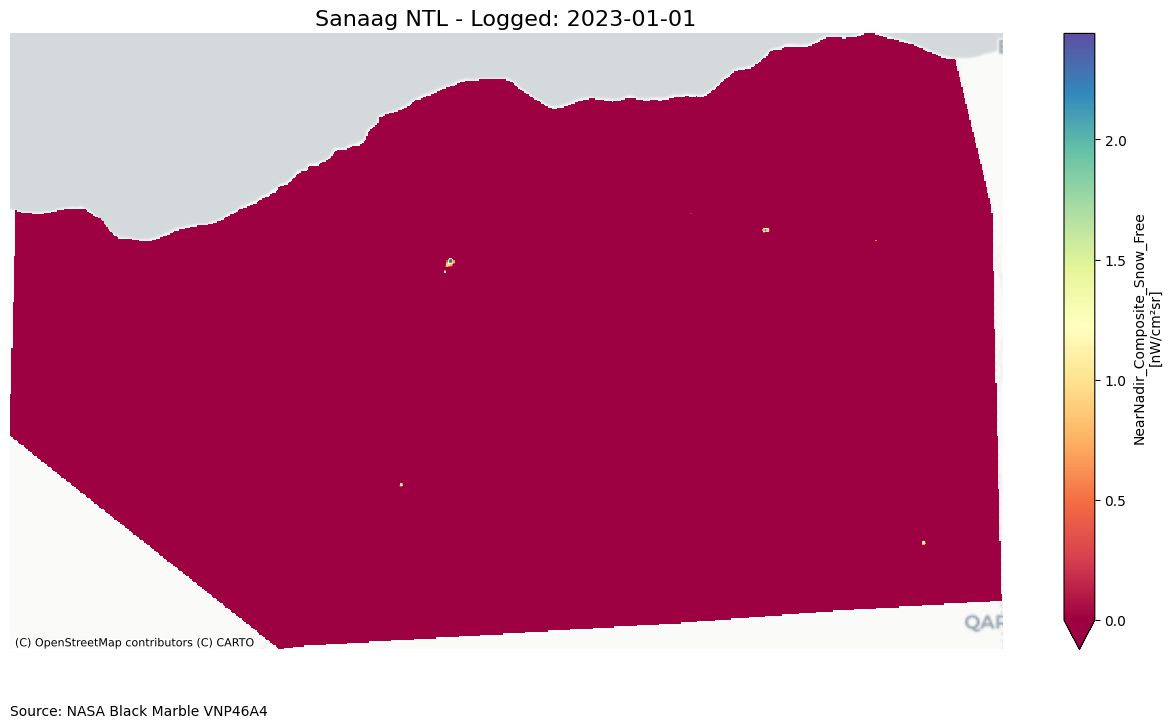

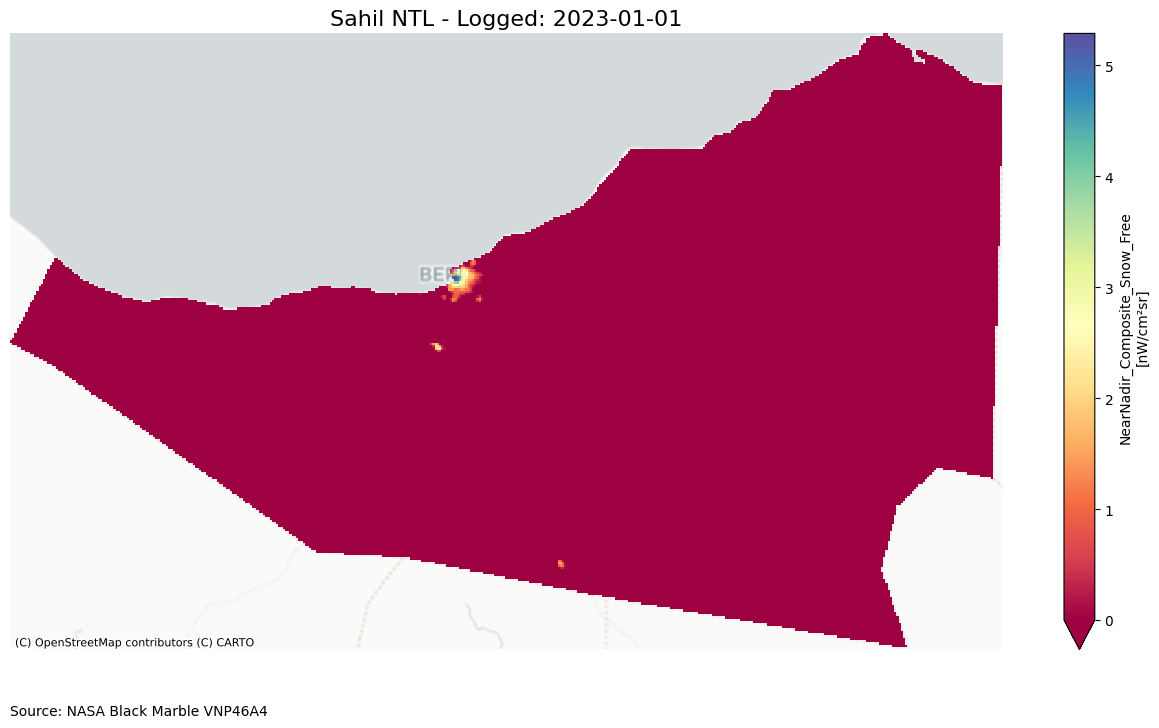

In [34]:
for year in [2012, 2023]:
    for region in regions_logged.keys():
        data = regions_logged[region]
        plot_NASA_NTL(data, somaliland_shp_berbera[somaliland_shp_berbera["admin1Name"]==f"{region}"], date = f"{year}-01-01", 
                      variable = "NearNadir_Composite_Snow_Free",
                      title_prefix = f"{region} NTL - Logged",
                      robust = False, vmin=0, vmax = data["NearNadir_Composite_Snow_Free"].max())
        plt.savefig(f'../output/Graphics/{region}_{year}.png', dpi=300, bbox_inches='tight')

## Urban

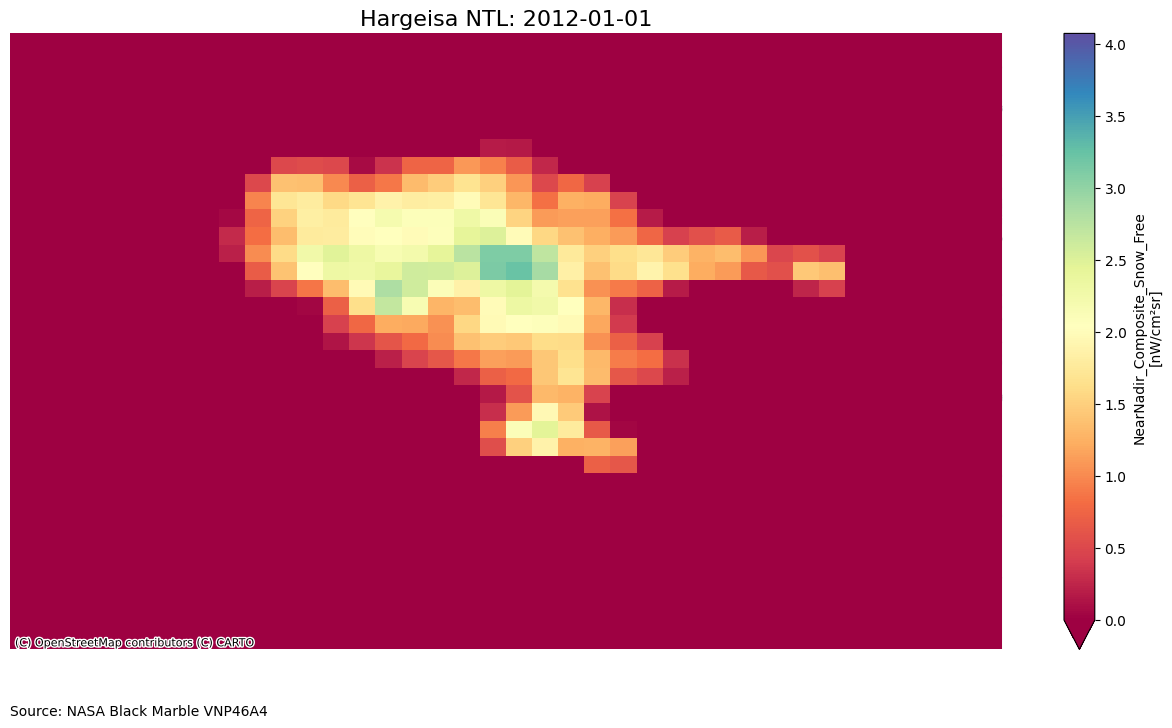

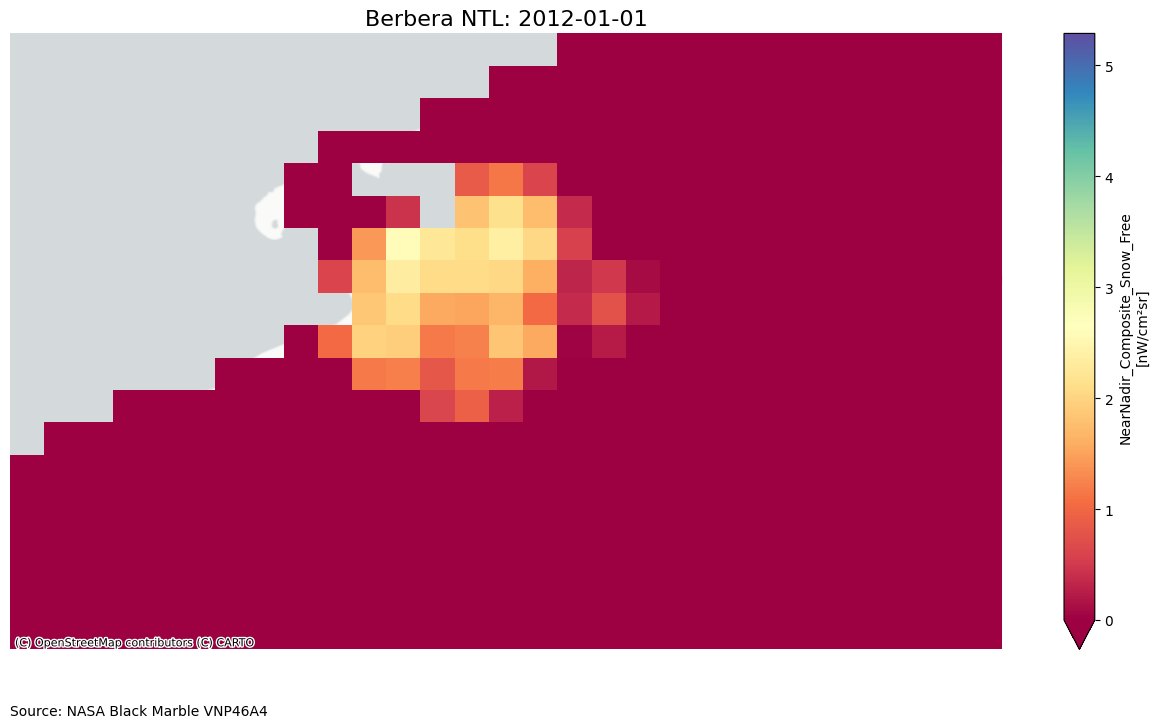

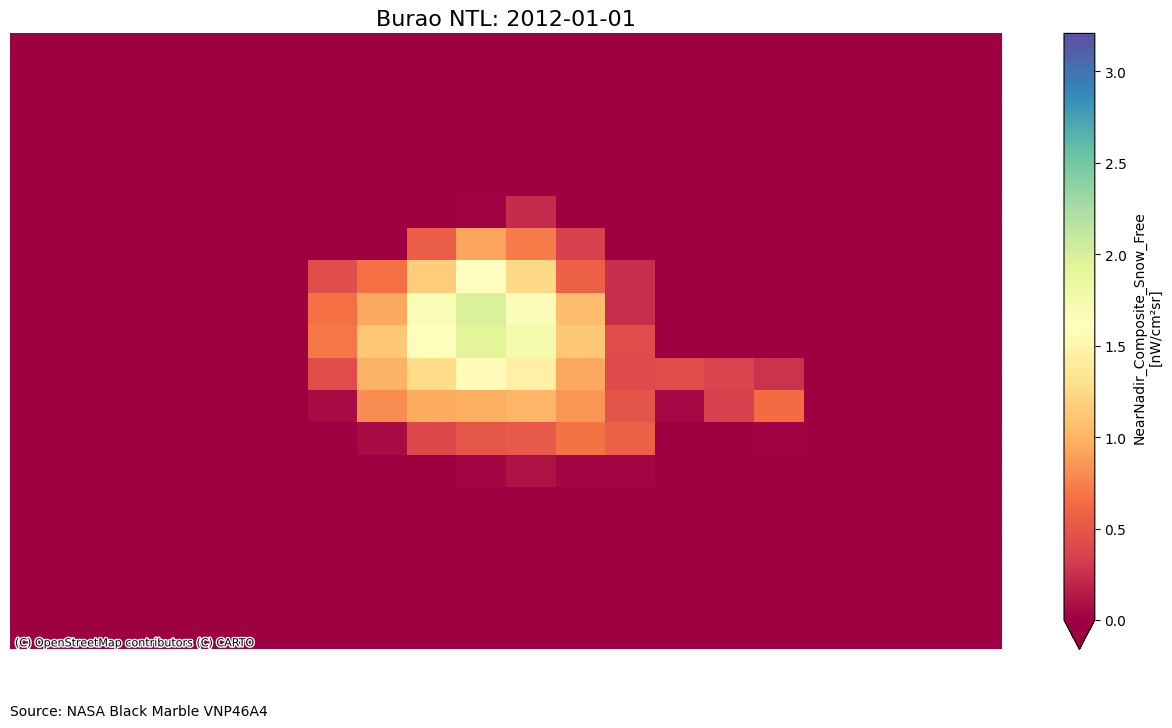

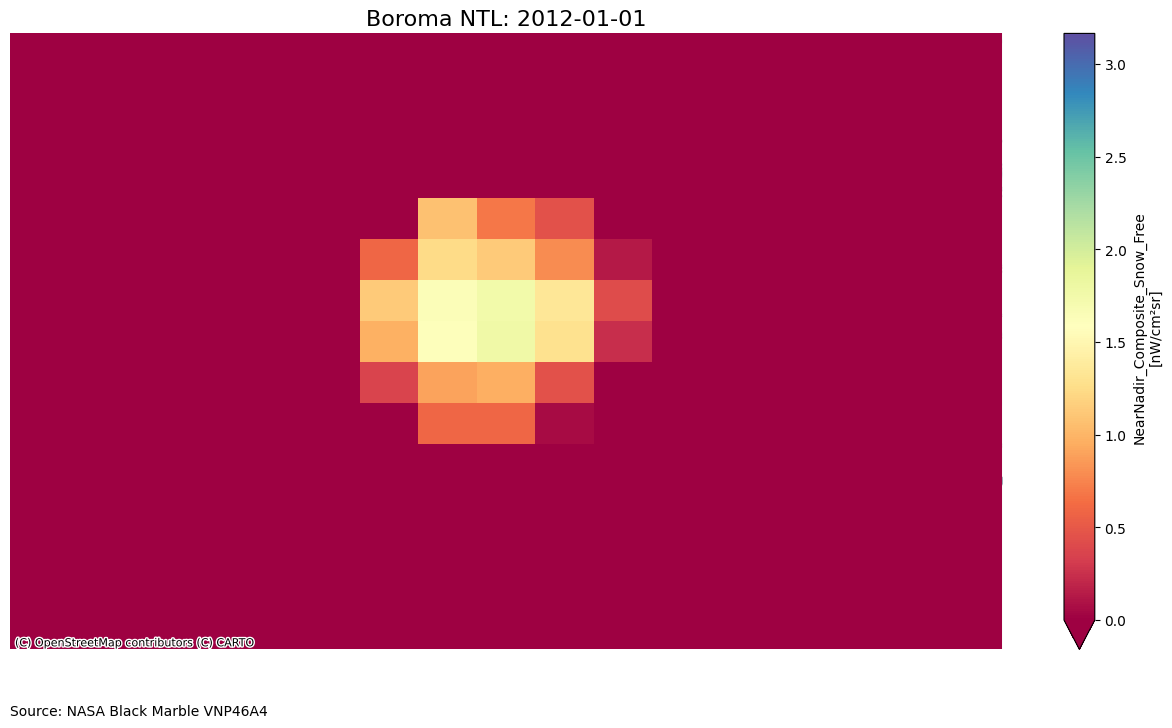

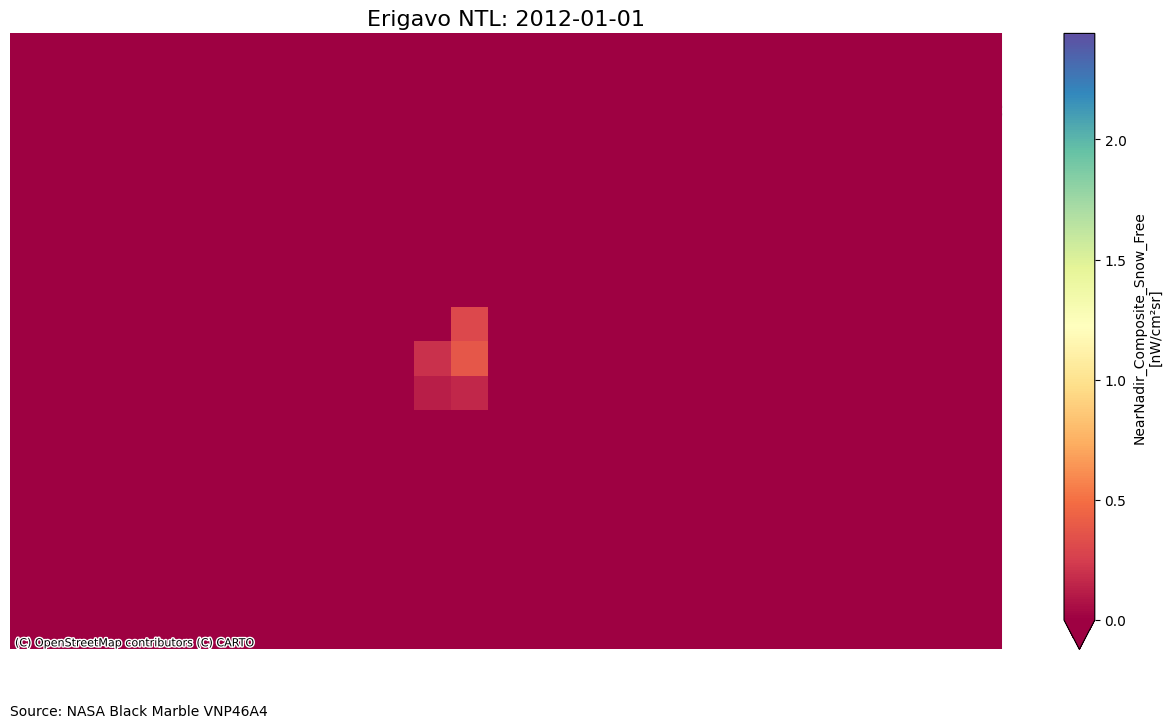

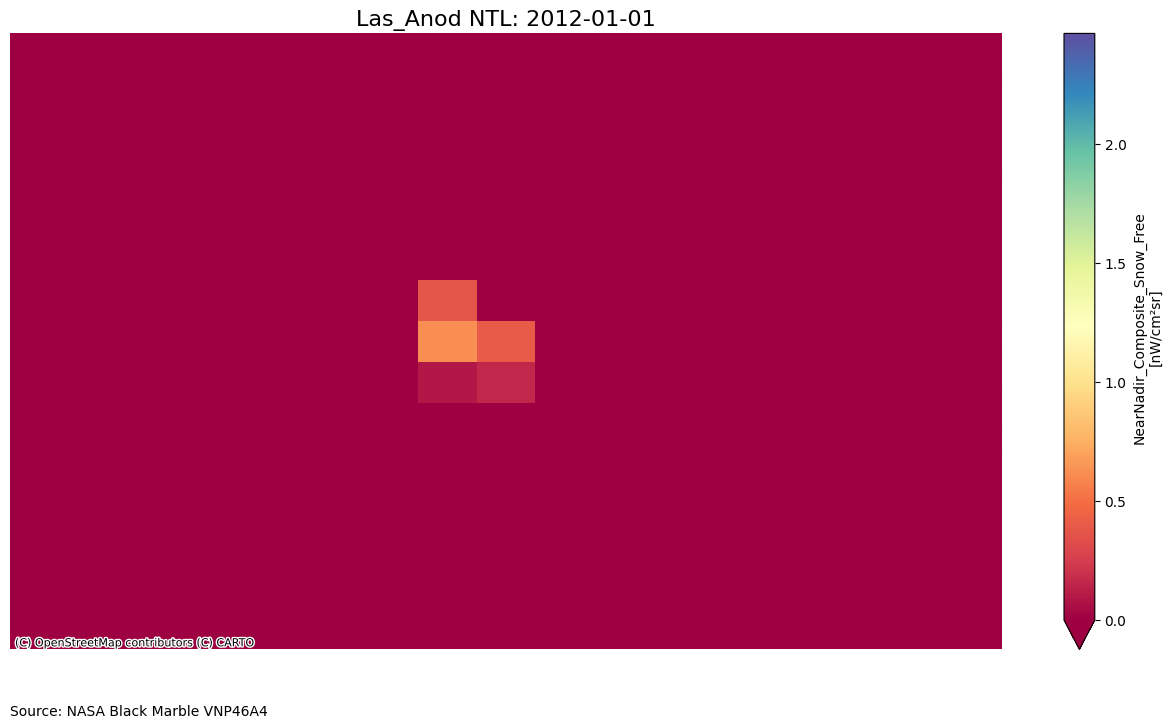

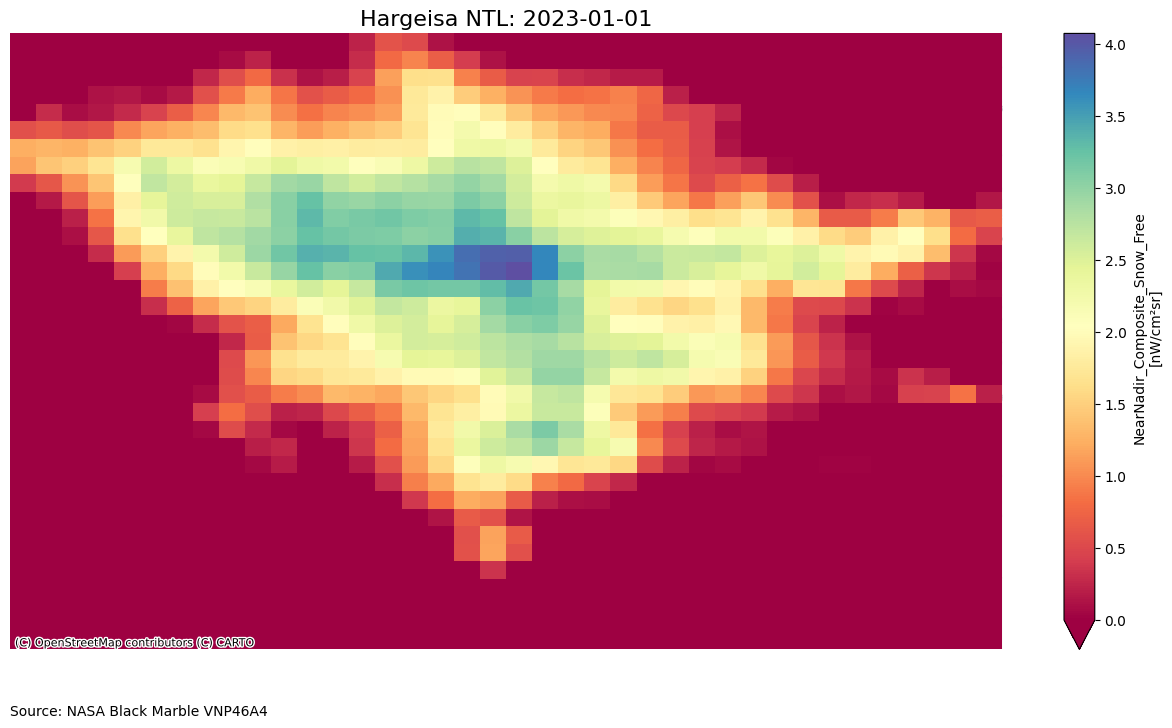

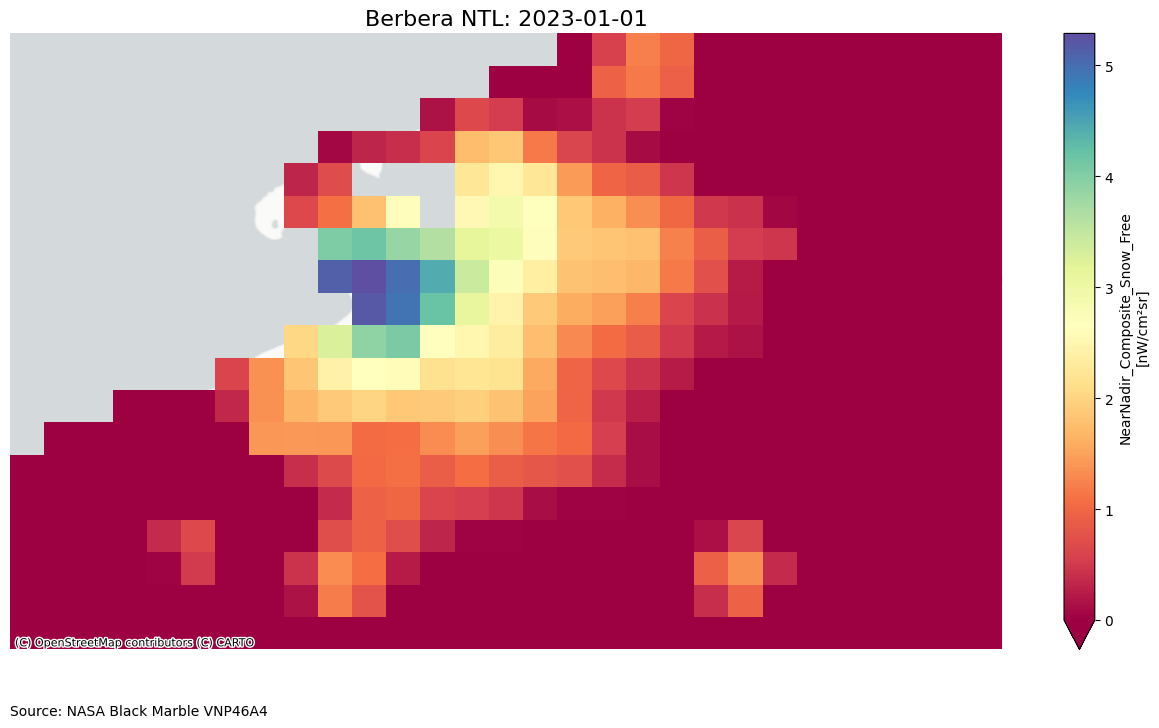

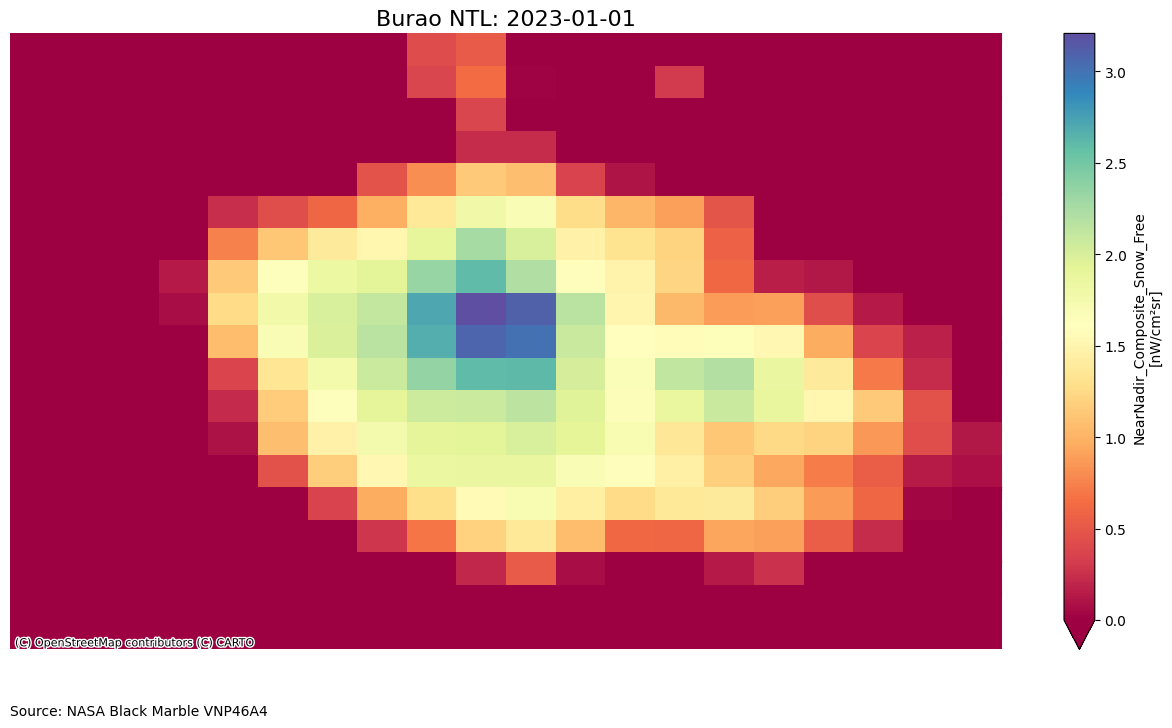

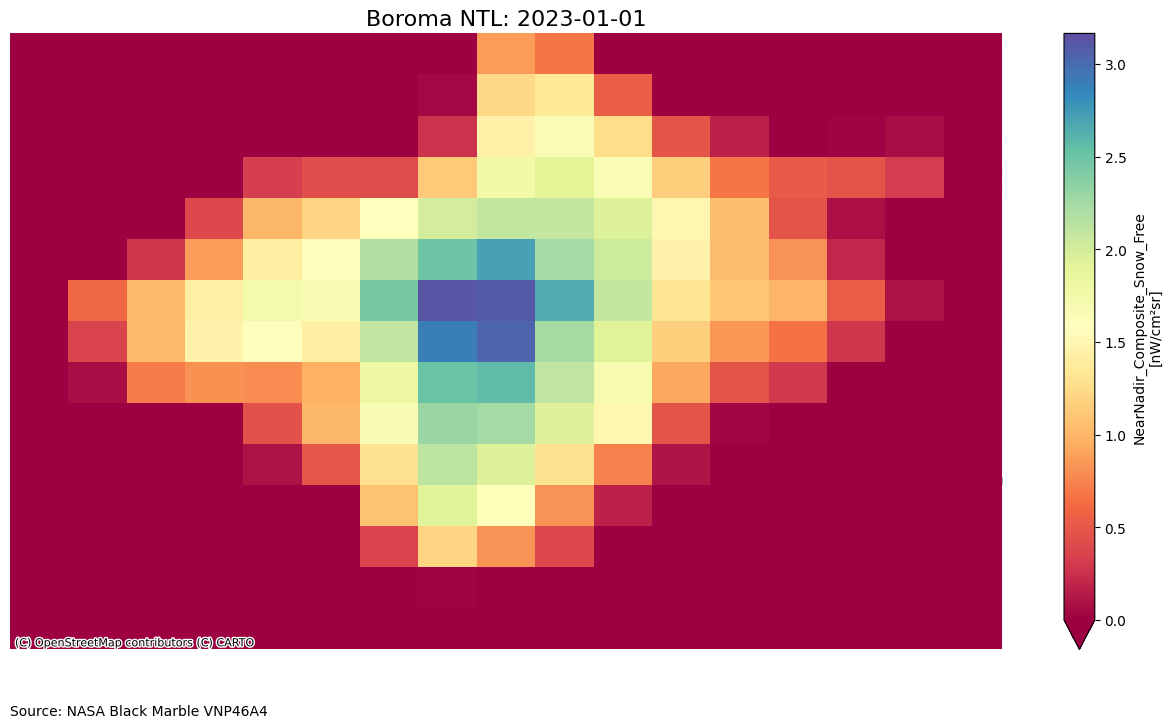

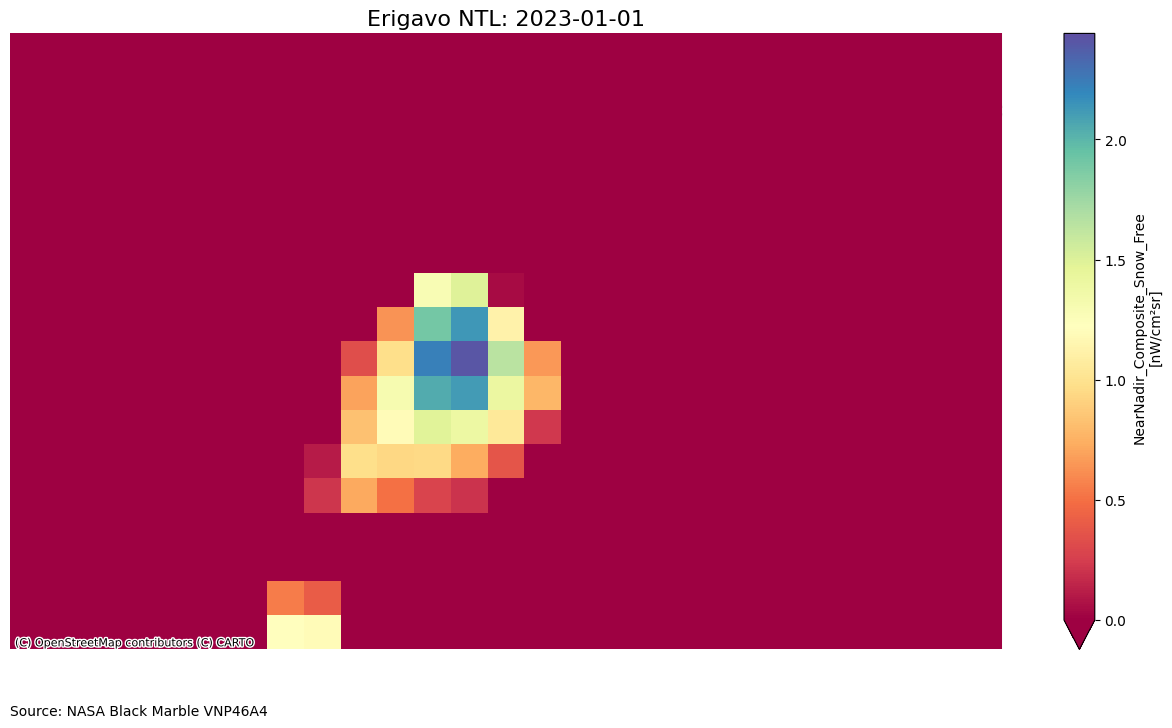

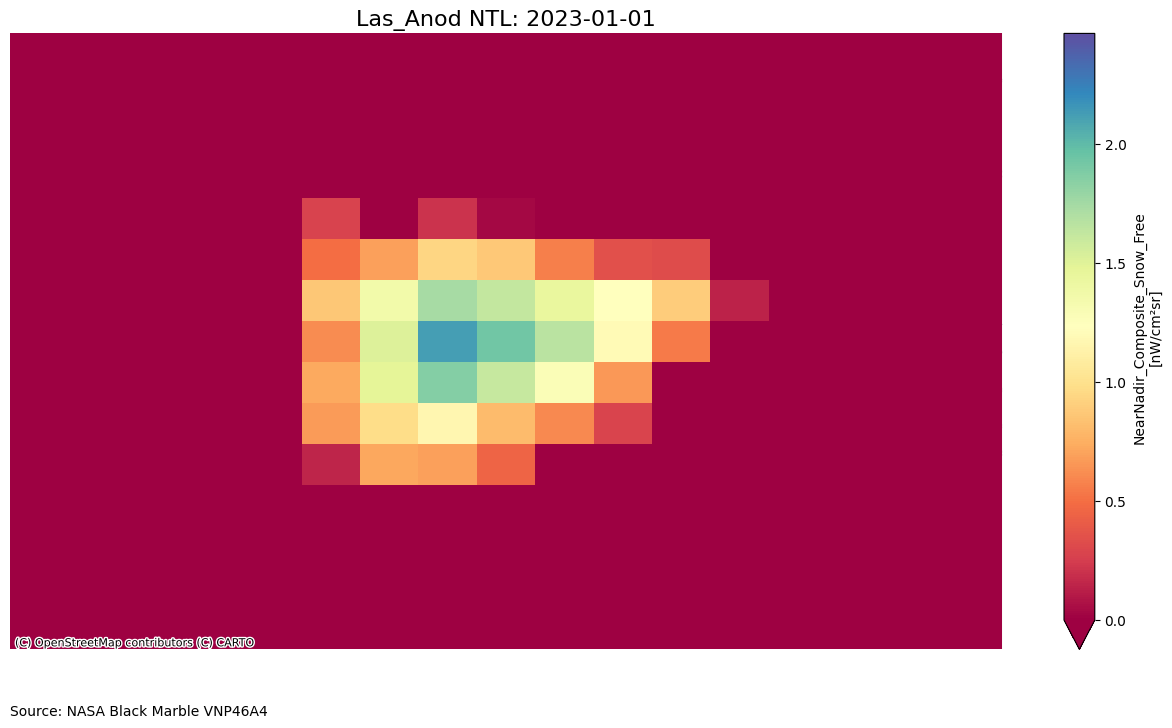

In [35]:
for year in [2012, 2023]:
    for city in cities_ntl.keys():
        plot_NASA_NTL(cities_ntl_logged[city], cities[city], date = f"{year}-01-01", 
                    variable = "NearNadir_Composite_Snow_Free",
                    title_prefix = f"{city} NTL",
                    robust = False, vmin=0, vmax = cities_ntl_logged[city]["NearNadir_Composite_Snow_Free"].max())
        plt.savefig(f'../output/Graphics/{city}_{year}_Logged.png', dpi=300, bbox_inches='tight')

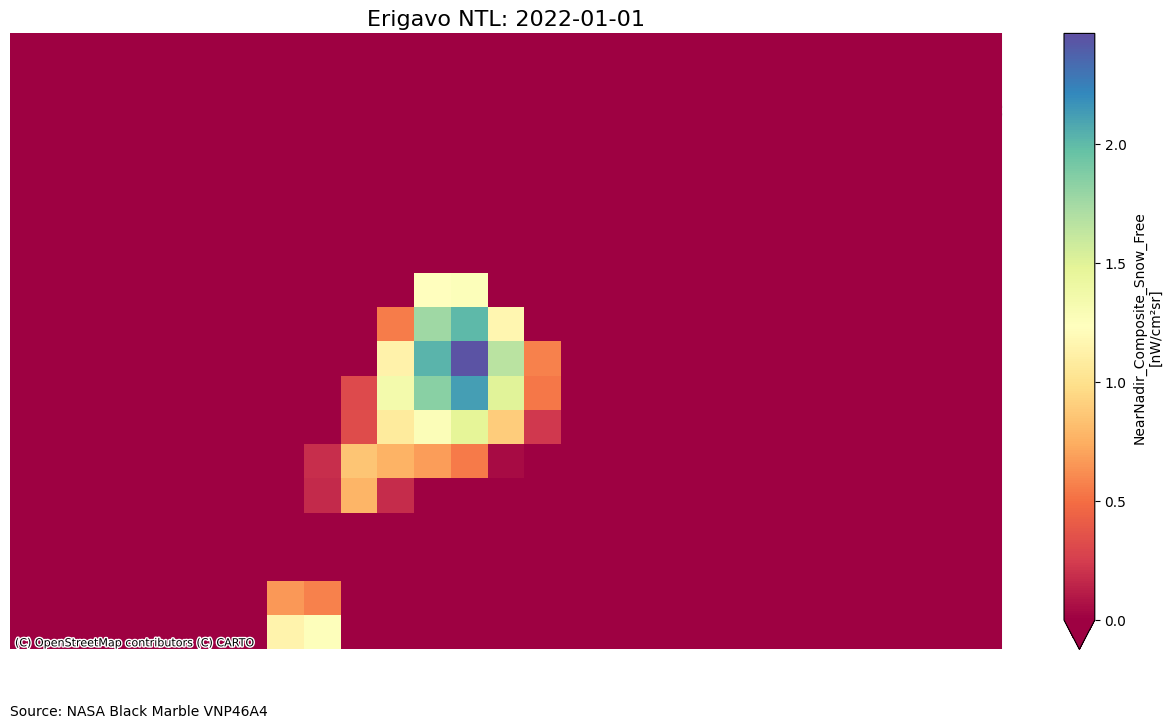

In [36]:
plot_NASA_NTL(cities_ntl_logged["Erigavo"], cities["Erigavo"], date = "2022-01-01", 
                    variable = "NearNadir_Composite_Snow_Free",
                    title_prefix = "Erigavo NTL",
                    robust = False, vmin=0, vmax = cities_ntl_logged[city]["NearNadir_Composite_Snow_Free"].max())
plt.savefig(f'../output/Graphics/{city}_{year}_Logged.png', dpi=300, bbox_inches='tight')

## Regional Share of NTL Rad & Pixels

In [ ]:
YEARS = np.arange(2012, 2024)
regions = {"Maroodi Jeex":[], "Togdheer":[], "Awdal":[], "Sool":[], "Sanaag":[], "Sahil":[]}
for region in regions:
    regions[region] = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_berbera, somaliland_shp_berbera[somaliland_shp_berbera["admin1Name"]==region]), somaliland_shp_berbera[somaliland_shp_berbera["admin1Name"]== region])

region_rad_df = pd.DataFrame({
    region: yearly_radiance(region_data, YEARS)
    for region, region_data in regions.items()
})
region_rad_df["Total"] = region_rad_df.sum(axis=1)
region_rad_df.insert(0, "Year", YEARS)
region_rad_df = region_rad_df.set_index("Year")
shares_rad = region_rad_df[region_rad_df.columns[:-1]].div(region_rad_df["Total"], axis=0)

region_pixel_df = pd.DataFrame({
    region: yearly_nonzero_pixels(region_data, YEARS)
    for region, region_data in regions.items()
})
region_pixel_df["Total"] = region_pixel_df.sum(axis=1)
region_pixel_df.insert(0, "Year", YEARS)
region_pixel_df = region_pixel_df.set_index("Year")
shares_pixels = region_pixel_df[region_pixel_df.columns[:-1]].div(region_pixel_df["Total"], axis=0)

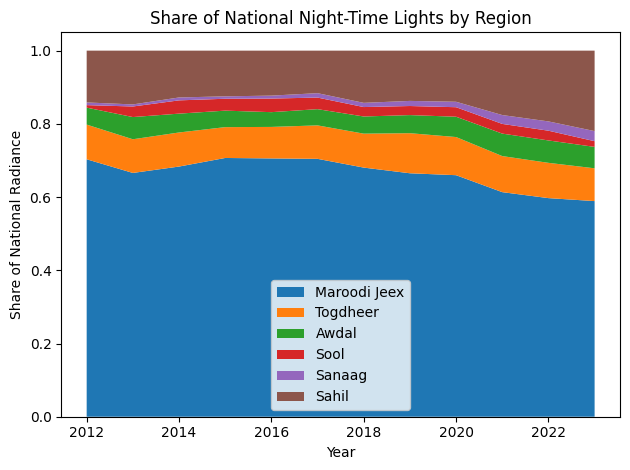

In [ ]:
plt.figure()
plt.stackplot(
    shares_rad.index,
    shares_rad.T,
    labels=region_rad_df.columns
)

plt.title("Share of National Night-Time Lights by Region")
plt.ylabel("Share of National Radiance")
plt.xlabel("Year")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


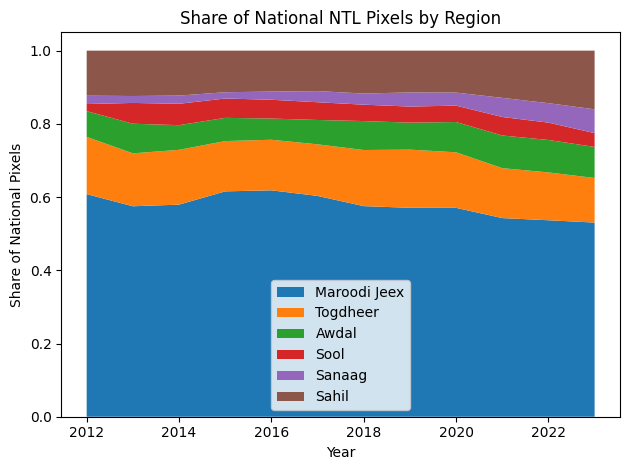

In [62]:
plt.figure()
plt.stackplot(
    shares_pixels.index,
    shares_pixels.T,
    labels=region_pixel_df.columns
)

plt.title("Share of National NTL Pixels by Region")
plt.ylabel("Share of National Pixels")
plt.xlabel("Year")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## Average Radiance per Region

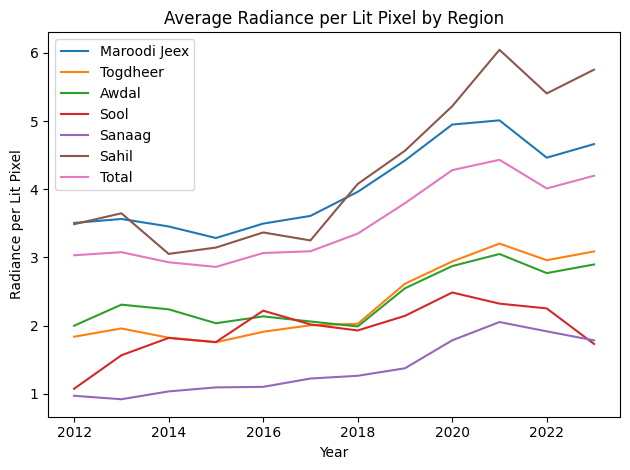

In [63]:
avg_rad_region = (
    region_rad_df[region_rad_df.columns] /
    region_pixel_df[region_pixel_df.columns]
)

plt.figure()
for region in region_rad_df.columns:
    plt.plot(avg_rad_region.index, avg_rad_region[region], label=region)

plt.title("Average Radiance per Lit Pixel by Region")
plt.xlabel("Year")
plt.ylabel("Radiance per Lit Pixel")
plt.legend()
plt.tight_layout()
plt.show()


<xarray.Dataset> Size: 124MB
Dimensions:                        (time: 12, y: 843, x: 1535)
Coordinates:
  * time                           (time) datetime64[ns] 96B 2012-01-01 ... 2...
  * y                              (y) float64 7kB 11.51 11.51 ... 8.006 8.002
  * x                              (x) float64 12kB 42.69 42.69 ... 49.07 49.08
Data variables:
    NearNadir_Composite_Snow_Free  (time, y, x) float64 124MB nan nan ... nan
Attributes: (12/42)
    AlgorithmType:                     b'SCI'
    AlgorithmVersion:                  b'NPP_PR46A3 2.0.0'
    Conventions:                       b'CF-1.6'
    creator_email:                     b'modis-ops@lists.nasa.gov'
    creator_name:                      b'VIIRS Land SIPS Processing Group'
    creator_url:                       b'https://ladsweb.modaps.eosdis.nasa.gov'
    ...                                ...
    VerticalTileNumber:                b'08'
    WestBoundingCoord:                 40.0
    AREA_OR_POINT:                     Area
    scale_factor:                      1.0
    add_offset:                        0.0
    _FillValue:                        nan

In [65]:

df = (
    SL_berbera["NearNadir_Composite_Snow_Free"]
    .to_dataframe(name="radiance")
    .reset_index()
)

df["year"] = df["time"].dt.year
df.drop(columns="time", inplace=True)

df["pixel_id"] = (
    df.groupby(["x", "y"]).ngroup()
)

df["lit"] = df["radiance"] > 0


In [66]:
df.head()

,y,x,radiance,year,pixel_id,lit
0,11.510435,42.685539,NaN,2012,842,False
1,11.510435,42.689705,NaN,2012,1685,False
2,11.510435,42.693872,NaN,2012,2528,False
3,11.510435,42.698039,NaN,2012,3371,False
4,11.510435,42.702205,NaN,2012,4214,False


In [67]:
df.describe()

,y,x,radiance,year,pixel_id
count,1.552806e+07,1.552806e+07,9.652500e+06,1.552806e+07,1.552806e+07
mean,9.756247e+00,4.588137e+01,5.646636e-03,2.017500e+03,6.470020e+05
std,1.013983e+00,1.846318e+00,2.949625e-01,3.452053e+00,3.735471e+05
min,8.002059e+00,4.268554e+01,0.000000e+00,2.012000e+03,0.000000e+00
25%,8.877070e+00,4.428137e+01,0.000000e+00,2.014750e+03,3.235010e+05
50%,9.756247e+00,4.588137e+01,0.000000e+00,2.017500e+03,6.470020e+05
75%,1.063542e+01,4.748137e+01,0.000000e+00,2.020250e+03,9.705030e+05
max,1.151044e+01,4.907721e+01,1.981849e+02,2.023000e+03,1.294004e+06


In [68]:
birth_year = (
    df[df["lit"]]
    .groupby("pixel_id")["year"]
    .min()
    .rename("birth_year")
)

df = df.merge(birth_year, on="pixel_id", how="left")
df["age"] = df["year"] - df["birth_year"]

df = df.sort_values(["pixel_id", "year"])

df["lit_next_year"] = (
    df.groupby("pixel_id")["lit"]
      .shift(-1)
)

df["survives_next_year"] = df["lit"] & df["lit_next_year"]

In [73]:
df[df["birth_year"].notna()].groupby("birth_year")["pixel_id"].nunique().sum()


np.int64(2694)

In [74]:
df[df["age"] == 0]["radiance"]


13377560    0.564213
14670030    0.637107
12083556    0.692966
12082021    0.780582
14668496    0.502942
              ...   
9612161     0.705185
13492641    0.597974
13500317    0.506123
14789717    0.501110
9612162     0.575263
Name: radiance, Length: 2694, dtype: float64

In [71]:
df[df["birth_year"] == 2016].groupby("age")["survives_next_year"].mean()


age
-4.0    0.000
-3.0    0.000
-2.0    0.000
-1.0    0.000
 0.0    0.875
 1.0    0.825
 2.0    0.825
 3.0    0.825
 4.0    0.850
 5.0    0.950
 6.0    0.950
 7.0    0.000
Name: survives_next_year, dtype: float64

<Axes: title={'center': 'radiance'}, xlabel='survives_next_year'>

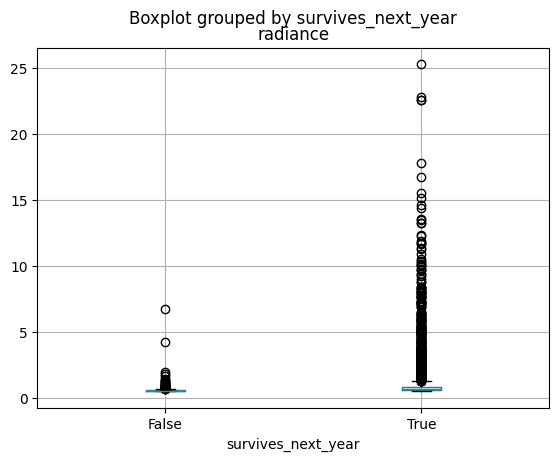

In [72]:
df[df["age"] == 0].boxplot(column="radiance", by="survives_next_year")

<Axes: xlabel='birth_year'>

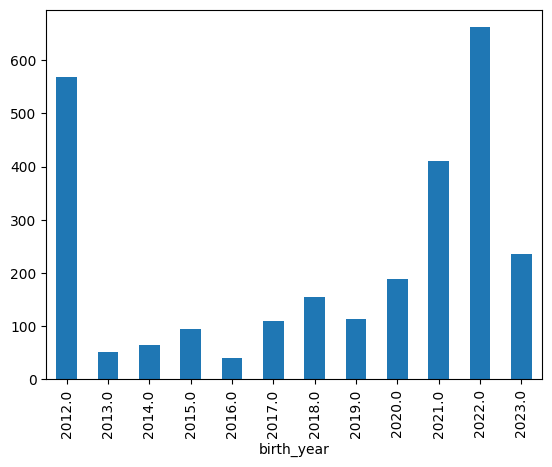

In [75]:
birth_counts = (
    df[df["birth_year"].notna()]
    .groupby("birth_year")["pixel_id"]
    .nunique()
)

birth_counts.plot(kind="bar")

,y,x,radiance,year,pixel_id,lit,birth_year,age,lit_next_year,survives_next_year
1292470,8.002059,42.685539,NaN,2012,0,False,NaN,NaN,False,False
2586475,8.002059,42.685539,NaN,2013,0,False,NaN,NaN,False,False
3880480,8.002059,42.685539,NaN,2014,0,False,NaN,NaN,False,False
5174485,8.002059,42.685539,NaN,2015,0,False,NaN,NaN,False,False
6468490,8.002059,42.685539,NaN,2016,0,False,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...
9059569,11.510435,49.077205,NaN,2019,1294004,False,NaN,NaN,False,False
10353574,11.510435,49.077205,NaN,2020,1294004,False,NaN,NaN,False,False
11647579,11.510435,49.077205,NaN,2021,1294004,False,NaN,NaN,False,False
12941584,11.510435,49.077205,NaN,2022,1294004,False,NaN,NaN,False,False


<Axes: title={'center': 'radiance'}, xlabel='birth_year'>

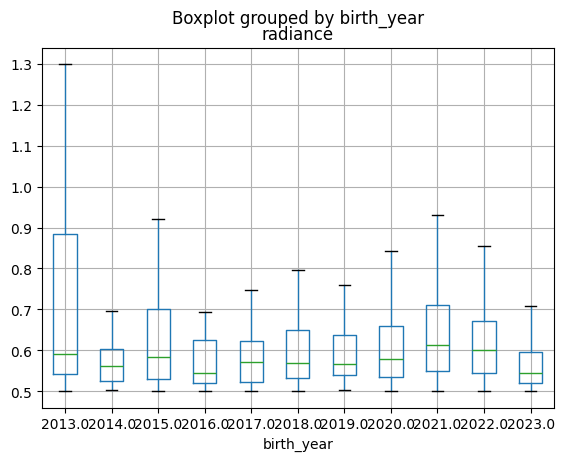

In [80]:
birth_df = df[(df["year"]!=2012) & (df["age"]==0)]

birth_df.boxplot(
    column="radiance",
    by="birth_year",
    showfliers=False
)

Text(0.5, 0, 'Years since birth')

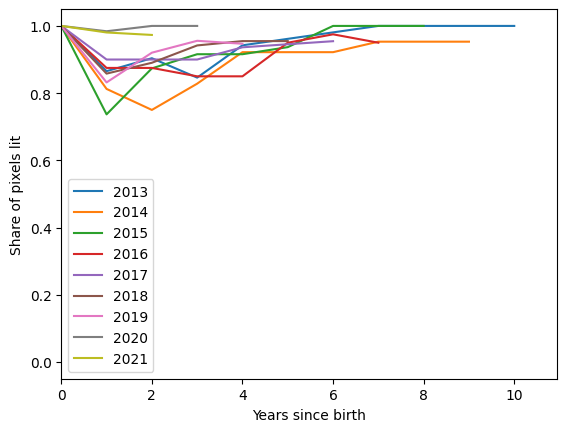

In [88]:
def survival_curve(birth_year):
    cohort = df[df["birth_year"] == birth_year]
    return (
        cohort.groupby("age")["lit"]
        .mean()
    )

for y in [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]:
    survival_curve(y).plot(label=str(y))

plt.xlim(0)
plt.legend()
plt.ylabel("Share of pixels lit")
plt.xlabel("Years since birth")